# 04 · Breaking one GPU

Phases 1 to 3 sent requests one at a time. This phase sends **more and more at once** until the RTX 5090 can't keep up, and records exactly what gives way first and why. The result is the **baseline** every later phase has to beat.

All numbers are read from `results/04_breaking_one_gpu/`.

## How the load was applied

* **Locust**, closed loop: each simulated user sends its next request as soon as the last one finishes, so *users = requests in flight*.
* **Steps:** 1, 2, 4, 8, 16, 32, 64, 96, 128, 192, 256, 384, 512 users, 60 s each. The first 15 s of every step is skipped in the analysis, so each row describes the system after it settled.
* **Traffic mix:** the 24 prompts from `loadtest/prompts.json`, weighted like a chat product: 35% short questions, 25% multi-turn, 25% document summaries (~500 to 1,100 prompt tokens), 15% long answers (up to 768 output tokens). Every request gets a **unique tag** at the start of the user message, so repeated prompts can't be served from the prefix cache.
* **Engine:** the Phase 0 baseline config (`vllm/configs/baseline.yaml`), unchanged.
* **Gateway:** every harness on, except rate limits and load shedding, which are raised out of the way so the test measures the GPU and not the per-user limits.
* **Server side** numbers come from Prometheus over the same windows: requests running and waiting in vLLM, KV cache usage, preemptions, tokens per second, GPU utilization and power.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
RESULTS = ROOT / "results" / "04_breaking_one_gpu"
sys.path.insert(0, str(ROOT / "loadtest"))
from results_logger import load_runs

runs = load_runs("04_breaking_one_gpu")
sweep = next((r for r in reversed(runs) if r["name"].startswith("load_sweep_")), None)
agents = next((r for r in reversed(runs) if r["name"] == "agent_load"), None)
print(f"load sweep: {sweep['name'] if sweep else None} | agent load: {bool(agents)}")
if sweep:
    env = sweep["environment"]
    gpu = env["gpus"][0] if env["gpus"] else {"name": "no GPU", "memory_mib": 0}
    print(f"hardware: {gpu['name']} | model: {sweep['config'].get('model')} | vLLM: {sweep['config'].get('vllm_image')} "
          f"| config: {sweep['config'].get('vllm_config')} | {sweep['metrics']['total_requests']:,} requests")

load sweep: load_sweep_baseline | agent load: True
hardware: NVIDIA GeForce RTX 5090 | model: Qwen/Qwen2.5-7B-Instruct | vLLM: vllm/vllm-openai:v0.30.0 | config: baseline | 11,175 requests


## Every step

In [2]:
def v(d, *keys):
    for k in keys:
        d = (d or {}).get(k)
    return d

def cell(value, fmt, width, scale=1, unit=""):
    return ("-" if value is None else format(value * scale, fmt) + unit).rjust(width)

if not sweep:
    print("No load sweep yet: run scripts/run_phase4.sh on the GPU box, then copy results/ back.")
else:
    steps = sweep["metrics"]["steps"]
    print(f"{'users':>6}{'req/s':>8}{'out tok/s':>11}{'TTFT p50':>10}{'TTFT p95':>10}{'TTFT p99':>10}{'e2e p95':>9}"
          f"{'ITL p50':>9}{'running':>9}{'waiting':>9}{'KV max':>8}{'preempt':>9}{'GPU':>6}{'power':>7}{'errors':>8}")
    for s in steps:
        sv = s.get("server", {})
        print(cell(s["users"], "d", 6) + cell(s["requests_per_s"], ".2f", 8) + cell(sv.get("output_tokens_per_s"), ".0f", 11)
              + cell(s["ttft_s"]["p50"], ".0f", 10, 1000, "ms") + cell(s["ttft_s"]["p95"], ".0f", 10, 1000, "ms")
              + cell(s["ttft_s"]["p99"], ".0f", 10, 1000, "ms") + cell(s["e2e_s"]["p95"], ".1f", 9, 1, "s")
              + cell(s["itl_s"]["p50"], ".1f", 9, 1000, "ms") + cell(v(sv, "running", "avg"), ".0f", 9)
              + cell(v(sv, "waiting", "max"), ".0f", 9) + cell(v(sv, "kv_cache_usage", "max"), ".0%", 8)
              + cell(sv.get("preemptions"), ".0f", 9) + cell(v(sv, "gpu_utilization", "avg"), ".0%", 6)
              + cell(v(sv, "gpu_power_w", "avg"), ".0f", 7, 1, "W") + cell(s["errors"], "d", 8))

 users   req/s  out tok/s  TTFT p50  TTFT p95  TTFT p99  e2e p95  ITL p50  running  waiting  KV max  preempt   GPU  power  errors
     1    0.58        102      24ms      62ms      73ms     3.8s    9.7ms        1        0      0%        0  100%   475W       0
     2    1.04        197      40ms      62ms      92ms     6.6s    9.9ms        2        0      1%        0  100%   427W       0
     4    1.69        393      39ms      77ms      97ms     7.6s   10.0ms        4        0      1%        0  100%   445W       0
     8    3.64        767      41ms      88ms     101ms     7.9s   10.2ms        8        0      2%        0  100%   473W       0
    16    6.00       1381      42ms      95ms     107ms     8.8s   11.4ms       16        0      4%        0  100%   484W       0
    32   11.33       2551      54ms     113ms     136ms     9.4s   12.2ms       32        0      8%        0  100%   523W       0
    64   19.67       4054      73ms     135ms     178ms    11.7s   15.5ms       63        

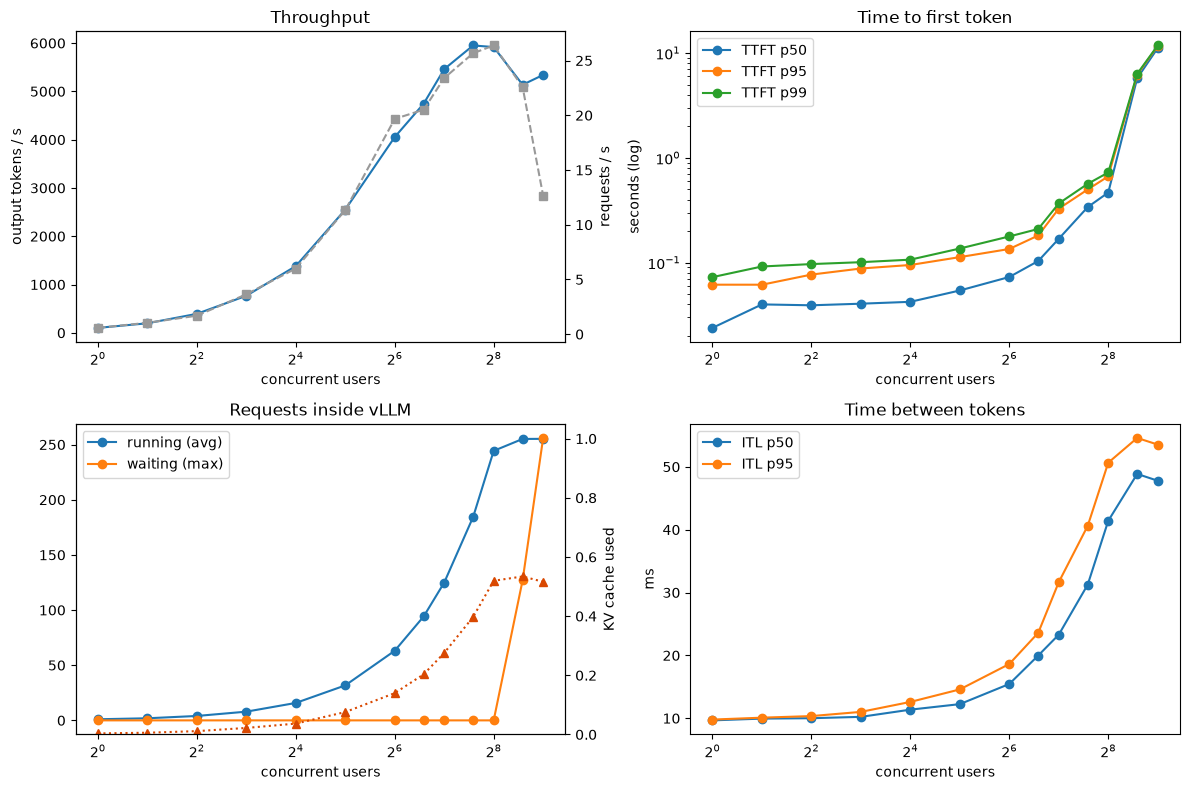

In [3]:
if sweep:
    users = [s["users"] for s in steps]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    ax = axes[0][0]
    ax.plot(users, [v(s, "server", "output_tokens_per_s") for s in steps], "o-", label="output tokens/s")
    ax.set_title("Throughput"); ax.set_ylabel("output tokens / s")
    ax2 = ax.twinx(); ax2.plot(users, [s["requests_per_s"] for s in steps], "s--", color="#999", label="requests/s")
    ax2.set_ylabel("requests / s")

    ax = axes[0][1]
    for key, label in (("p50", "TTFT p50"), ("p95", "TTFT p95"), ("p99", "TTFT p99")):
        ax.plot(users, [s["ttft_s"][key] for s in steps], "o-", label=label)
    ax.set_yscale("log"); ax.set_title("Time to first token"); ax.set_ylabel("seconds (log)"); ax.legend()

    ax = axes[1][0]
    ax.plot(users, [v(s, "server", "running", "avg") for s in steps], "o-", label="running (avg)")
    ax.plot(users, [v(s, "server", "waiting", "max") for s in steps], "o-", label="waiting (max)")
    ax.set_title("Requests inside vLLM"); ax.legend()
    ax3 = ax.twinx(); ax3.plot(users, [v(s, "server", "kv_cache_usage", "max") for s in steps], "^:", color="#d94801", label="KV cache (max)")
    ax3.set_ylabel("KV cache used"); ax3.set_ylim(0, 1.05)

    ax = axes[1][1]
    ax.plot(users, [s["itl_s"]["p50"] and s["itl_s"]["p50"] * 1000 for s in steps], "o-", label="ITL p50")
    ax.plot(users, [s["itl_s"]["p95"] and s["itl_s"]["p95"] * 1000 for s in steps], "o-", label="ITL p95")
    ax.set_title("Time between tokens"); ax.set_ylabel("ms"); ax.legend()

    for ax in axes.flat:
        ax.set_xscale("log", base=2); ax.set_xlabel("concurrent users")
    plt.tight_layout(); plt.show()

**Reading the last step:** Locust stops the moment the last step ends, and requests still in flight at that point are never logged, mostly long answers (only 9 long generations finished in the 512 user window). So the 512 row's client side requests/s and end to end time are flattered. The server side columns (tokens/s, running, waiting, KV) come from vLLM and are not affected.

**GPU utilization** reads 100% even with one user: `nvidia-smi` utilization means "a kernel was running", not "the GPU is fully used". Power draw is the better load signal here: 475 W at 1 user, at the 575 W cap from 96 users on.

## Where it broke

The first user count at which each kind of trouble showed up. `ttft_p95_over_slo` uses a 1 s target for time to first token.

In [4]:
if sweep:
    for k, val in sweep["metrics"]["breaking_points"].items():
        print(f"{k:<28}{val}")

requests_queue              384
kv_cache_95pct              None
preemptions                 None
ttft_p95_over_slo           384
errors_over_1pct            None
peak_throughput_users       192
peak_output_tokens_per_s    5951.0888888888885
ttft_slo_s                  1.0


### Capacity at different latency targets

The highest user count in the sweep that still meets each target (closed loop, this traffic mix).

In [5]:
if sweep:
    targets = [("TTFT p95 < 200 ms", lambda s: s["ttft_s"]["p95"] < 0.2),
               ("TTFT p95 < 500 ms", lambda s: s["ttft_s"]["p95"] < 0.5),
               ("TTFT p95 < 1 s", lambda s: s["ttft_s"]["p95"] < 1.0),
               ("ITL p50 < 20 ms (50+ tokens/s per user)", lambda s: s["itl_s"]["p50"] < 0.020),
               ("ITL p50 < 40 ms (25+ tokens/s per user)", lambda s: s["itl_s"]["p50"] < 0.040)]
    for name, ok in targets:
        passing = [s for s in steps if ok(s)]
        best = max(passing, key=lambda s: s["users"]) if passing else None
        print(f"{name:<42}" + (f"{best['users']:>4} users, {v(best, 'server', 'output_tokens_per_s'):>5.0f} output tokens/s" if best else "none"))

TTFT p95 < 200 ms                           96 users,  4746 output tokens/s
TTFT p95 < 500 ms                          192 users,  5951 output tokens/s
TTFT p95 < 1 s                             256 users,  5918 output tokens/s
ITL p50 < 20 ms (50+ tokens/s per user)     96 users,  4746 output tokens/s
ITL p50 < 40 ms (25+ tokens/s per user)    192 users,  5951 output tokens/s


In [6]:
if sweep:
    print("p95 by request type at each step (TTFT / end to end):")
    cats = sorted({c for s in steps for c in s["by_category"]})
    print(f"{'users':>6}" + "".join(f"{c:>26}" for c in cats))
    for s in steps:
        print(f"{s['users']:>6}" + "".join(
            cell(v(s, "by_category", c, "ttft_p95_s"), ".2f", 12, 1, "s") + " /" + cell(v(s, "by_category", c, "e2e_p95_s"), ".1f", 11, 1, "s")
            for c in cats))

p95 by request type at each step (TTFT / end to end):
 users           long_generation                multi_turn                  short_qa             summarization
     1       0.02s /       7.4s       0.03s /       2.5s       0.02s /       0.6s       0.07s /       3.8s
     2       0.07s /       7.7s       0.04s /       2.8s       0.04s /       0.7s       0.09s /       3.9s
     4       0.04s /       7.9s       0.04s /       2.8s       0.04s /       0.7s       0.10s /       3.8s
     8       0.10s /       8.4s       0.05s /       2.9s       0.04s /       0.7s       0.10s /       4.1s
    16       0.06s /       9.4s       0.05s /       3.3s       0.06s /       0.8s       0.11s /       4.4s
    32       0.07s /      11.2s       0.08s /       3.6s       0.09s /       0.9s       0.13s /       5.0s
    64       0.11s /      14.5s       0.13s /       4.3s       0.12s /       1.1s       0.17s /       6.3s
    96       0.15s /      16.8s       0.17s /       5.7s       0.17s /       1.4s     

## Is something other than the GPU the bottleneck?

Container CPU sampled every 10 s during the run (`docker stats`). The gateway is a single Python process that streams every token; if it maxes out a core before the GPU is busy, the GPU isn't the limit.

In [7]:
stats_file = RESULTS / "baseline" / "container_stats.jsonl"
if sweep and stats_file.exists():
    rows = [json.loads(l) for l in stats_file.read_text().splitlines() if l.strip()]
    meta_start = sweep["load"]["start"]
    names = sorted({r["name"].replace("llm-inference-ops-", "").rsplit("-", 1)[0] for r in rows})
    print(f"{'users':>6}" + "".join(f"{n:>14}" for n in names) + "   (max CPU %, 100% = one core)")
    for s in steps:
        a, b = s["window"]
        in_win = [r for r in rows if a <= r["t"] < b]
        line = f"{s['users']:>6}"
        for n in names:
            vals = [float(r["cpu"].rstrip("%")) for r in in_win if n in r["name"]]
            line += cell(max(vals) if vals else None, ".0f", 13, 1, "%")
        print(line)
else:
    print("No container stats.")

 users       gateway  gpu-exporter       grafana        jaeger    locust-run         nginx    prometheus          vllm   (max CPU %, 100% = one core)
     1           4%          11%           0%           0%           3%           3%           1%          34%
     2           9%           0%           0%           0%           6%           4%           2%          55%
     4          23%           0%           0%           0%          15%           8%           2%          62%
     8          23%           0%           1%           0%          14%           7%           1%          61%
    16          25%           0%           0%           0%          15%           7%           1%          41%
    32          53%           8%           0%           1%          29%          15%           0%          92%
    64          56%          11%           0%           5%          99%          24%           0%         116%
    96          60%          12%           0%           1%          62%  

## Concurrent agents

`scripts/agent_load.py` starts N CrewAI crews at the same moment (3 dependent LLM calls each), with a unique tag per task.

In [8]:
if agents:
    print(f"{'crews':>6}{'task p50':>10}{'task p95':>10}{'tasks/min':>11}{'out tok/s':>11}{'failed':>8}   per agent p50")
    for lv in agents["metrics"]["levels"]:
        t, sv = lv["task_s"], lv.get("server") or {}
        print(f"{lv['concurrent_crews']:>6}{cell(t.get('p50'), '.1f', 9, 1, 's')}{cell(t.get('p95'), '.1f', 9, 1, 's')}"
              f"{lv['tasks_per_minute']:>11.1f}{cell(sv.get('output_tokens_per_s'), '.0f', 11)}{lv['failed']:>8}   "
              + ", ".join(f"{a.split()[0].lower()} {s:.1f}s" for a, s in lv["per_agent_p50_s"].items() if s))
else:
    print("No agent load run yet.")

 crews  task p50  task p95  tasks/min  out tok/s  failed   per agent p50
     1     8.5s     8.5s        5.8         55       0   incident 4.6s, reviewer 2.3s, technical 1.6s
     4     8.8s     8.9s       21.7        182       0   incident 4.8s, reviewer 2.3s, technical 1.6s
     8     8.9s     9.0s       43.1        272       0   incident 5.0s, reviewer 2.1s, technical 1.7s
    16     9.9s    10.3s       77.0        825       0   incident 5.6s, reviewer 2.3s, technical 1.8s
    32    10.3s    11.0s      138.7       1760       0   incident 6.0s, reviewer 2.3s, technical 1.9s


## Grafana and Locust

Locust's live view of the whole ramp: requests per second climbs and then flattens around 50, the 95th percentile response time climbs steadily, and failures stay at 0% all the way to 512 users.

![Locust](images/04_breaking_one_gpu/locust_charts.png)

Locust's own summary for the whole run (all steps together, so these percentiles mix light and heavy load): ~10,700 requests in each row pair and **0 failures**. Each request appears twice, once as `TOTAL` (end to end) and once as `TTFT`.

![Locust statistics](images/04_breaking_one_gpu/locust_statistics.png)

The load generator was never the bottleneck: at 512 users, each of the 8 Locust workers ran 64 users at **5 to 7% CPU**.

![Locust workers](images/04_breaking_one_gpu/locust_workers.png)

The engine capacity row tells the story of the break: requests running climbs with users and **flattens at exactly 256**, the moment the waiting queue appears, while KV cache usage tops out around 50% and there are no preemptions.

![Engine capacity](images/04_breaking_one_gpu/grafana_engine_capacity.png)

![Latency](images/04_breaking_one_gpu/grafana_latency.png)

![GPU](images/04_breaking_one_gpu/grafana_gpu.png)

## What happened

**1. Throughput grows almost linearly, then hits a ceiling around 192 users.** Output tokens per second went 102 → 1,381 → 4,054 → 5,951 from 1 to 16 to 64 to 192 users, then stayed flat (5,918 at 256). Batching is what makes one GPU serve many users: at 64 users it produced **40× the tokens** of one user. Past ~128 users, extra users mostly add waiting.

**2. Every user pays for the batch in decode speed.** Time between tokens rose from **9.7 ms at 1 user** to 15.5 ms at 64, 31 ms at 192 and 41 ms at 256: each user's answer streams 4× slower so the GPU can serve 250 of them. The GPU sat at its **575 W power limit from 96 users onwards**, so beyond that point it simply had no more to give.

**3. The cliff is a setting, not memory.** At 384 users, time to first token jumped from 0.5 s to **5.8 s at the median**, and to 11 s at 512. The cause is visible directly: vLLM ran at most **256 requests at once** (`max-num-seqs`, its default) and everything beyond waited in a queue of up to 256. The KV cache never passed **53%** and there were **zero preemptions**. Memory was not the limit for this traffic; the scheduler cap and the GPU's compute were.

**4. Where the GPU breaks depends on the target.** With TTFT p95 under 200 ms it serves **96 users** (~4,700 tokens/s); under 500 ms, **192 users** (~5,950 tokens/s, the throughput peak); under 1 s, **256 users**. Beyond 256 users nothing meets any reasonable TTFT target. These become the SLO candidates for Phase 5.

**5. Nothing failed.** 11,175 requests, 0 errors, even with 256 queued. The system degrades by getting slower, not by breaking. That's good for reliability, but it means a user can wait 11 s for a first token, which is why load shedding (a harness already built in Phase 3) matters once real limits are known.

**6. The gateway is not the bottleneck yet, but it's closer than expected.** At peak the gateway used **84% of one CPU core** (it's a single Python process streaming every token), NGINX 47%, vLLM's own API server 116%. At a higher token rate (a faster GPU or Phase 6's multiple vLLMs) the gateway would need more workers.

**7. Agents scale well within the cap.** 32 CrewAI crews at once took **10.3 s per task instead of 8.5 s** (+21%) while completing **24× as many tasks per minute** (139 vs 5.8). Each crew's 3 sequential calls ride on the same batching.

**What Phase 5 will test:** raising `max-num-seqs` (the KV cache is half empty, so more requests fit), and seeing whether that buys throughput or only trades queueing for slower decode; chunked prefill and batched token limits for TTFT; and FP8 to fit more and compute faster.

## Phase 4 exit criteria

- [x] Locust step load test with per-request client measurements and server metrics per step
- [x] Concurrent CrewAI crews as a second, realistic load
- [x] Automatic breaking-point detection: queueing, KV cache full, preemptions, TTFT over target, errors
- [x] Phase 4 session on the RTX 5090, 1 to 512 users
- [x] Breaking point documented with its root cause